In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Chemin du dataset
root_image_dir = '/content/drive/MyDrive/archive (10)/ECG_DATA'

# Fonction pour parcourir les sous-dossiers
def check_dataset_structure(root_dir):
    for split in ['train', 'test']:  # 'train' et 'test' sont les répertoires principaux
        split_path = os.path.join(root_dir, split)

        if os.path.isdir(split_path):
            print(f"Contenu du répertoire {split}:")
            # Liste des classes (les répertoires dans train et test)
            for class_dir in os.listdir(split_path):
                class_path = os.path.join(split_path, class_dir)
                if os.path.isdir(class_path):
                    print(f"  - {class_dir}: {len(os.listdir(class_path))} sous-dossiers")
                else:
                    print(f"  - {class_dir} n'est pas un dossier.")
        else:
            print(f"{split} n'existe pas dans {root_dir}")

# Vérifier la structure du dataset
check_dataset_structure(root_image_dir)


Contenu du répertoire train:
  - MI: 791 sous-dossiers
  - Abnormal: 791 sous-dossiers
  - History_MI: 785 sous-dossiers
  - Normal: 791 sous-dossiers
Contenu du répertoire test:
  - MI: 228 sous-dossiers
  - Abnormal: 228 sous-dossiers
  - History_MI: 222 sous-dossiers
  - Normal: 228 sous-dossiers


In [ ]:
import os
import pandas as pd

# 📍 Chemins vers les dossiers train et test
train_dir = '/content/drive/MyDrive/archive (10)/ECG_DATA/train'
test_dir = '/content/drive/MyDrive/archive (10)/ECG_DATA/test'

# 📍 Mapping des dossiers vers les labels
label_mapping = {
    'MI': 'Malade',
    'Abnormal': 'Malade',
    'History_MI': 'Malade',
    'Normal': 'Normal'
}

# 📌 Fonction pour générer le dataframe à partir des images
def create_dataframe(data_dir):
    data = []
    for class_dir in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_dir)
        if os.path.isdir(class_path):
            label = label_mapping.get(class_dir)
            for file in os.listdir(class_path):
                file_path = os.path.join(class_path, file)
                # Si c'est une image
                if os.path.isfile(file_path) and file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    data.append({
                        'image_path': file_path,
                        'label': label
                    })
    return pd.DataFrame(data)

# 📦 Créer les dataframes train et test
df_train = create_dataframe(train_dir)
df_test = create_dataframe(test_dir)

# 📊 Afficher les premières lignes
print("Aperçu train :")
print(df_train.head())

print("\nAperçu test :")
print(df_test.head())

# 📊 Afficher la répartition des classes
print("\nRépartition des classes dans train :")
print(df_train['label'].value_counts())

print("\nRépartition des classes dans test :")
print(df_test['label'].value_counts())


Aperçu train :
                                          image_path   label
0  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade
1  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade
2  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade
3  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade
4  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade

Aperçu test :
                                          image_path   label
0  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade
1  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade
2  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade
3  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade
4  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade

Répartition des classes dans train :
label
Malade    2367
Normal     791
Name: count, dtype: int64

Répartition des classes dans test :
label
Malade    678
Normal    228
Name: count, dtype: int64


**nettoyage initiale**

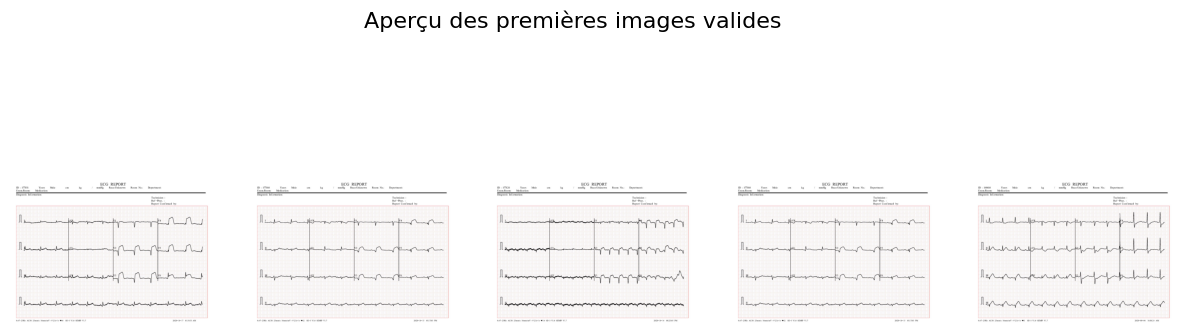

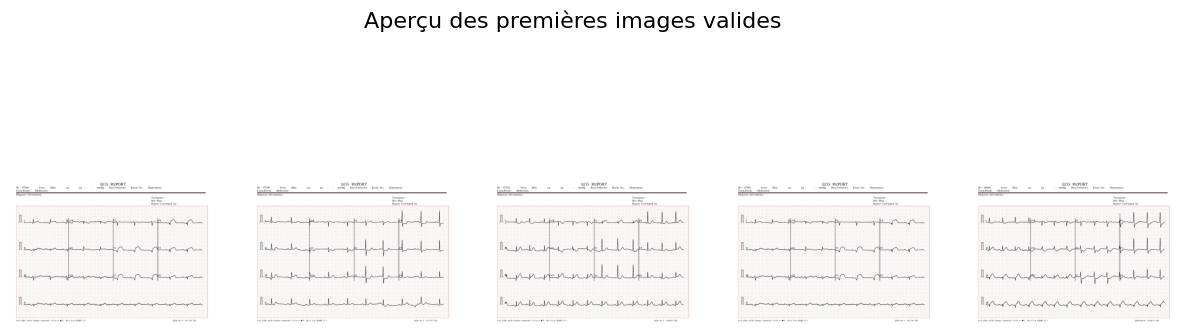

label
Malade    2367
Normal     791
Name: count, dtype: int64
label
Malade    678
Normal    228
Name: count, dtype: int64


In [ ]:
from PIL import Image, UnidentifiedImageError
import pandas as pd
import matplotlib.pyplot as plt

def nettoyer_dataframe(df, min_size=(100, 100), n_images_preview=5):
    chemins_valides = []
    labels_valides = []
    images_preview = []

    for idx, row in df.iterrows():
        path = row['image_path']
        label = row['label']
        try:
            with Image.open(path) as img:
                if img.size[0] >= min_size[0] and img.size[1] >= min_size[1]:
                    chemins_valides.append(path)
                    labels_valides.append(label)
                    if len(images_preview) < n_images_preview:
                        images_preview.append(img.copy())  # نحفظ نسخة من الصورة لعرضها بعد اللوب
                else:
                    print(f'Image trop petite : {path}')
        except (UnidentifiedImageError, FileNotFoundError, OSError) as e:
            print(f'Image corrompue ou introuvable : {path}')
            continue


    if images_preview:
        fig, axs = plt.subplots(1, len(images_preview), figsize=(15, 5))
        for ax, img in zip(axs, images_preview):
            ax.imshow(img)
            ax.axis('off')
        plt.suptitle("Aperçu des premières images valides", fontsize=16)
        plt.show()

    df_clean = pd.DataFrame({'image_path': chemins_valides, 'label': labels_valides})
    return df_clean

# 🔍 Nettoyer train et test avec affichage des miniatures
df_train_clean = nettoyer_dataframe(df_train)
df_test_clean = nettoyer_dataframe(df_test)

# 📊 Vérifier les nouvelles répartitions
print(df_train_clean['label'].value_counts())
print(df_test_clean['label'].value_counts())


 **équilibrée le dataset**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import numpy as np
import pandas as pd
import os
import shutil
import uuid
from PIL import Image

# 📁 Répertoire des images augmentées
augmented_dir = '/content/drive/MyDrive/ECG_DATA/augmented_normals'

# 🧹 Supprimer les anciennes images générées
if os.path.exists(augmented_dir):
    shutil.rmtree(augmented_dir)
os.makedirs(augmented_dir, exist_ok=True)

# 📊 Répartition avant augmentation
print("📊 Répartition avant augmentation :")
print(df_train_clean['label'].value_counts())

# 📂 Séparer les classes
normal_df = df_train_clean[df_train_clean['label'] == 'Normal']
malade_df = df_train_clean[df_train_clean['label'] == 'Malade']

# 📈 Nombre d'images à générer pour équilibrer les classes
n_to_generate = len(malade_df) - len(normal_df)
print(f"\nNormal : {len(normal_df)}, Malade : {len(malade_df)}, à générer : {n_to_generate}")

# ⚙️ Générateur d'images
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 🔁 Générer des images augmentées avec noms uniques
generated = 0
for idx, row in normal_df.iterrows():
    img = load_img(row['image_path'], color_mode='rgb')
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)

    for batch in datagen.flow(x, batch_size=1):
        # 🆔 Nom unique avec UUID
        unique_name = f"aug_{uuid.uuid4().hex}.jpg"
        save_path = os.path.join(augmented_dir, unique_name)

        # 📷 Sauvegarder manuellement l'image augmentée
        img_aug = batch[0].astype('uint8')
        Image.fromarray(img_aug).save(save_path)

        generated += 1
        if generated >= n_to_generate:
            break
    if generated >= n_to_generate:
        break

print(f"\n✅ {generated} images augmentées générées.")

# 📄 Créer DataFrame pour les images augmentées
augmented_images = [
    os.path.join(augmented_dir, f)
    for f in os.listdir(augmented_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]
augmented_df = pd.DataFrame({'image_path': augmented_images, 'label': 'Normal'})


# Fusionner les données : Malade (original) + Normal (augmenté)
df_train_balanced = pd.concat([malade_df, normal_df, augmented_df], ignore_index=True)

#Répartition finale équilibrée
print("\n📊 Répartition finale équilibrée :")
print(df_train_balanced['label'].value_counts())

# enregistrer CSV
df_train_balanced.to_csv('/content/drive/MyDrive/ECG_DATA/train_balanced.csv', index=False)
print("\n💾 CSV enregistré.")


📊 Répartition avant augmentation :
label
Malade    2367
Normal     791
Name: count, dtype: int64

Normal : 791, Malade : 2367, à générer : 1576

✅ 1576 images augmentées générées.

📊 Répartition finale équilibrée :
label
Malade    2367
Normal    2367
Name: count, dtype: int64

💾 CSV enregistré.


<ipython-input-9-3312011862>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train_balanced, x='label', palette='Set2')
<ipython-input-9-3312011862>:10: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


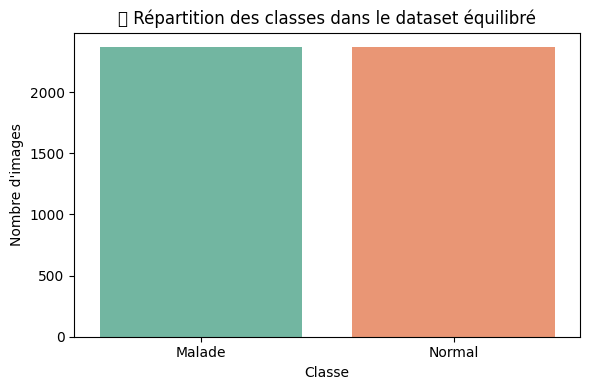

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df_train_balanced, x='label', palette='Set2')
plt.title('📊 Répartition des classes dans le dataset équilibré')
plt.xlabel('Classe')
plt.ylabel('Nombre d\'images')
plt.tight_layout()
plt.show()


In [ ]:
# 📁 Séparer les images "Malade" uniquement (pas tout le df_clean)
malade_df = df_train_clean[df_train_clean['label'] == 'Malade']

# 📁 Créer le dataframe final équilibré : Malade original + Normal généré
df_train_balanced = pd.concat([malade_df, augmented_df], ignore_index=True)


**generation des variable clinique**

In [ ]:
import numpy as np
import pandas as pd
import os


os.makedirs('/content/drive/MyDrive/datacombine9', exist_ok=True)

# 📌 Fonction: ajouter les 5 variables cliniques sans normalization
def add_clinical_features(df, split_name, out_csv):
    ef, bnp, nyha, sbp, age = [], [], [], [], []

    for _, row in df.iterrows():
        is_diseased = row['label'] != 'Normal'

        # -- EF (Fraction d'éjection) [0.20 - 0.75]
        mu_ef  = 0.60 if not is_diseased else 0.38
        sd_ef  = 0.07 if not is_diseased else 0.09
        ef_val = np.random.normal(mu_ef, sd_ef)
        ef_val = np.clip(ef_val, 0.20, 0.75)

        # -- BNP (pg/mL) [10 - 2000]
        mu_bnp  = 4.2 if not is_diseased else 5.8
        sd_bnp  = 0.6
        bnp_val = np.random.lognormal(mu_bnp, sd_bnp)
        bnp_val = np.clip(bnp_val, 10, 2000)

        # -- NYHA (1-4)
        probs   = [0.50, 0.30, 0.15, 0.05] if not is_diseased else [0.10, 0.30, 0.40, 0.20]
        nyha_cls = np.random.choice([1, 2, 3, 4], p=probs)

        # -- SBP (mmHg) [80 - 180]
        mu_sbp  = 125 if not is_diseased else 110
        sd_sbp  = 15
        sbp_val = np.random.normal(mu_sbp, sd_sbp)
        sbp_val = np.clip(sbp_val, 80, 180)

        # -- AGE (ans) [20 - 90]
        mu_age  = 55 if not is_diseased else 68
        sd_age  = 10
        age_val = np.random.normal(mu_age, sd_age)
        age_val = np.clip(age_val, 20, 90)

        # Append les valeurs
        ef.append(round(ef_val, 3))
        bnp.append(round(bnp_val, 3))
        nyha.append(nyha_cls)
        sbp.append(round(sbp_val, 1))
        age.append(int(round(age_val)))  # العمر كعدد صحيح

    # Ajouter les colonnes au DataFrame
    df['ef']   = ef
    df['bnp']  = bnp
    df['nyha'] = nyha
    df['sbp']  = sbp
    df['age']  = age

    # Sauvegarder le nouveau CSV
    df.to_csv(out_csv, index=False)
    print(f"[{split_name}] 📦 Clinical features saved in → {out_csv}")
    return df


# 📦 Appliquer sur tes datasets train et test
df_train_final = add_clinical_features(
    df_train_balanced, 'train', '/content/drive/MyDrive/datacombine9/train_top5.csv')

df_test_final = add_clinical_features(
    df_test_clean, 'test', '/content/drive/MyDrive/datacombine9/test_top5.csv')

# 📊 Aperçu final
print(df_train_final.head())
print(df_test_final.head())


[train] 📦 Clinical features saved in → /content/drive/MyDrive/datacombine9/train_top5.csv
[test] 📦 Clinical features saved in → /content/drive/MyDrive/datacombine9/test_top5.csv
                                          image_path   label     ef      bnp  \
0  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade  0.227   91.057   
1  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade  0.433  332.664   
2  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade  0.409  271.345   
3  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade  0.427  254.029   
4  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade  0.349  200.468   

   nyha    sbp  age  
0     3  116.5   79  
1     3  137.6   64  
2     4  108.2   83  
3     3  101.0   90  
4     4  116.8   73  
                                          image_path   label     ef      bnp  \
0  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade  0.394  236.559   
1  /content/drive/MyDrive/archive (10)/ECG_DATA/t

**nettoyage finale**

Total initial: 4734
Total après nettoyage: 4734
Lignes supprimées: 0

Distribution des labels:
label
Malade    2367
Normal    2367
Name: count, dtype: int64


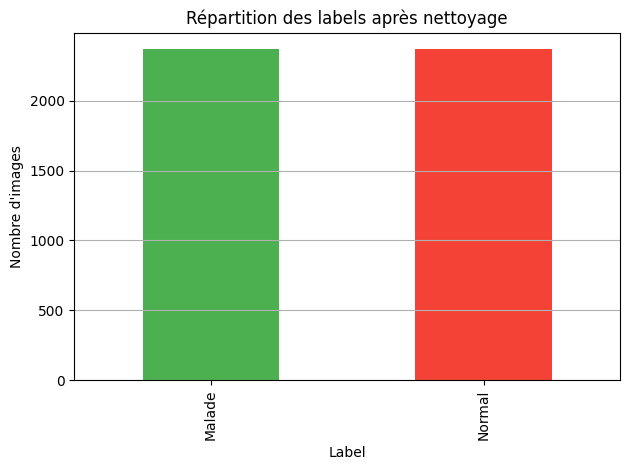


Aperçu des premières lignes :
                                          image_path   label     ef      bnp  \
0  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade  0.227   91.057   
1  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade  0.433  332.664   
2  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade  0.409  271.345   
3  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade  0.427  254.029   
4  /content/drive/MyDrive/archive (10)/ECG_DATA/t...  Malade  0.349  200.468   

   nyha    sbp  age  
0     3  116.5   79  
1     3  137.6   64  
2     4  108.2   83  
3     3  101.0   90  
4     4  116.8   73  


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt

def clean_dataframe(df, image_dir):
    df_init_len = len(df)

    # 1. Supprimer doublons exacts
    df = df.drop_duplicates()

    # 2. Supprimer lignes avec valeurs manquantes dans colonnes importantes
    cols_important = ['image_path', 'label']
    df = df.dropna(subset=cols_important)

    # 3. Vérifier existence des fichiers images
    def file_exists(row):
        return os.path.isfile(os.path.join(image_dir, row['image_path']))

    mask_exists = df.apply(file_exists, axis=1)
    df = df[mask_exists]

    # 4. Filtrer labels invalides
    valid_labels = ['Normal', 'Malade']
    df = df[df['label'].isin(valid_labels)]

    df = df.reset_index(drop=True)
    df_final_len = len(df)

    # 🔍 Affichage informatif
    print(f"Total initial: {df_init_len}")
    print(f"Total après nettoyage: {df_final_len}")
    print(f"Lignes supprimées: {df_init_len - df_final_len}")
    print("\nDistribution des labels:")
    print(df['label'].value_counts())

    # 📊 Histogramme simple
    df['label'].value_counts().plot(kind='bar', title="Répartition des labels après nettoyage", color=["#4CAF50", "#F44336"])
    plt.xlabel("Label")
    plt.ylabel("Nombre d'images")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # 👁️‍🗨️ Aperçu du DataFrame
    print("\nAperçu des premières lignes :")
    print(df.head())

    return df

# Chargement des données
df_train = pd.read_csv('/content/drive/MyDrive/datacombine9/train_top5.csv')
image_directory = '/content/drive/MyDrive/archive (10)/ECG_DATA'
df_cleaned = clean_dataframe(df_train, image_directory)


**division de data**

In [ ]:
from sklearn.model_selection import train_test_split

# Split 20%
df_train_split, df_val_split = train_test_split(
    df_train_final,
    test_size=0.16,
    stratify=df_train_final['label'],
    random_state=42
)

# Sauvegarde
df_train_split.to_csv('/content/drive/MyDrive/datacombine4/train_top5.csv', index=False)
df_val_split.to_csv('/content/drive/MyDrive/datacombine4/val_split.csv', index=False)

# Vérification
print(f"Train : {df_train_split.shape[0]} images")
print(f"Validation : {df_val_split.shape[0]} images")
print("\nRépartition des labels dans Train :")
print(df_train_split['label'].value_counts())
print("\nRépartition des labels dans Validation :")
print(df_val_split['label'].value_counts())


Train : 3976 images
Validation : 758 images

Répartition des labels dans Train :
label
Normal    1988
Malade    1988
Name: count, dtype: int64

Répartition des labels dans Validation :
label
Malade    379
Normal    379
Name: count, dtype: int64


**Distribution**

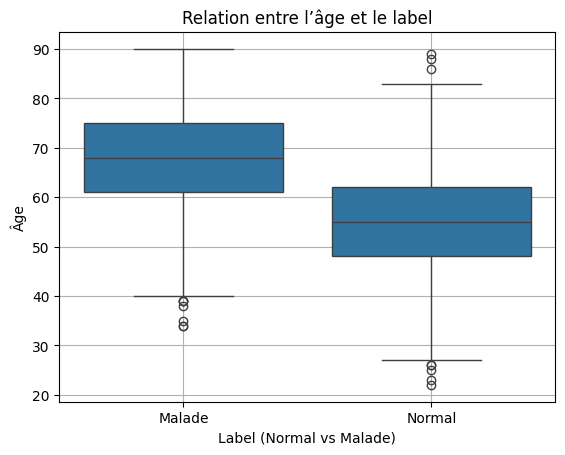

In [ ]:
sns.boxplot(x='label', y='age', data=df_train_final)
plt.title("Relation entre l’âge et le label")
plt.xlabel("Label (Normal vs Malade)")
plt.ylabel("Âge")
plt.grid(True)
plt.show()


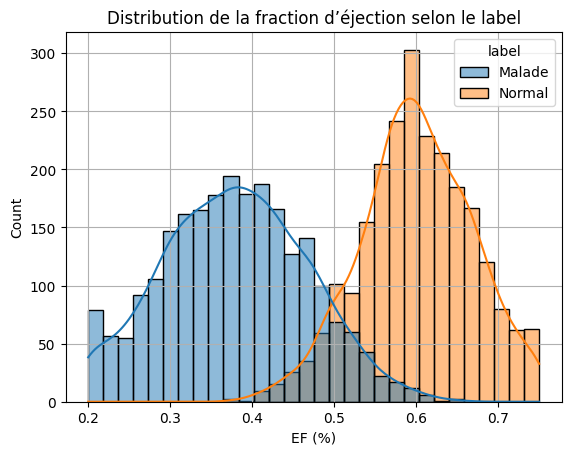

In [ ]:
sns.histplot(df_train_final, x='ef', hue='label', bins=30, kde=True)
plt.title("Distribution de la fraction d’éjection selon le label")
plt.xlabel("EF (%)")
plt.grid(True)
plt.show()


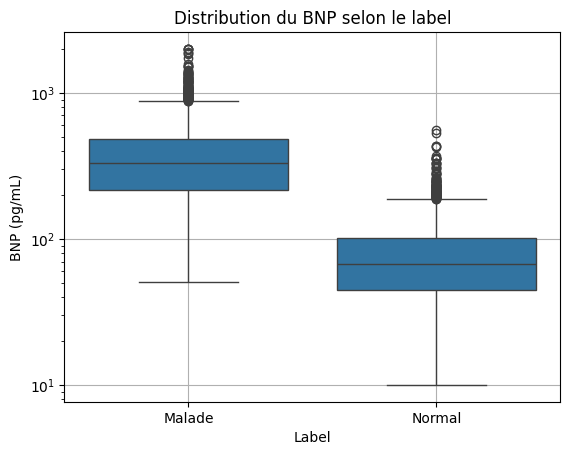

In [ ]:
sns.boxplot(x='label', y='bnp', data=df_train_final)
plt.title("Distribution du BNP selon le label")
plt.ylabel("BNP (pg/mL)")
plt.xlabel("Label")
plt.yscale('log')  # لأن BNP فيها skew
plt.grid(True)
plt.show()


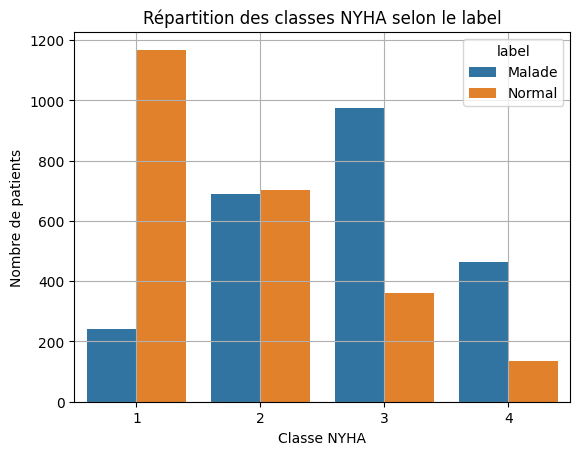

In [ ]:
sns.countplot(x='nyha', hue='label', data=df_train_final)
plt.title("Répartition des classes NYHA selon le label")
plt.xlabel("Classe NYHA")
plt.ylabel("Nombre de patients")
plt.grid(True)
plt.show()


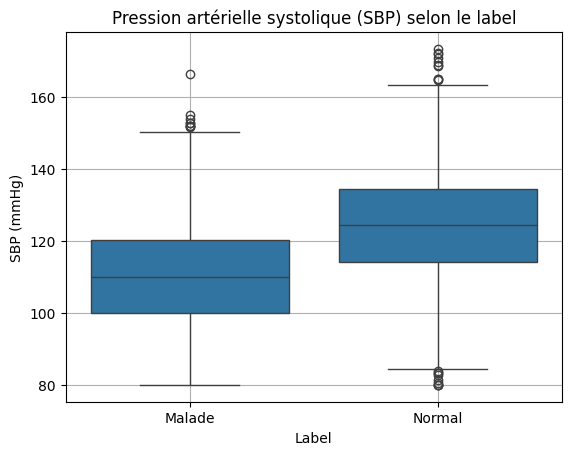

In [ ]:
sns.boxplot(x='label', y='sbp', data=df_train_final)
plt.title("Pression artérielle systolique (SBP) selon le label")
plt.ylabel("SBP (mmHg)")
plt.xlabel("Label")
plt.grid(True)
plt.show()


In [ ]:
pip install torch-geometric


**pretraitement**

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
from PIL import Image
from torchvision import models, transforms
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import kneighbors_graph
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import torch.nn as nn
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import joblib

# 📌 Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 📁 Paths
train_csv = '/content/drive/MyDrive/datacombine9/train_top5.csv'
val_csv   = '/content/drive/MyDrive/datacombine9/val_split.csv'
test_csv  = '/content/drive/MyDrive/datacombine9/test_top5.csv'
image_dir = '/content/drive/MyDrive/archive (10)/ECG_DATA'

# 📖 Load datasets
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

# 📊 Encode labels
label_encoder = LabelEncoder()
train_df['label'] = label_encoder.fit_transform(train_df['label'])
val_df['label']   = label_encoder.transform(val_df['label'])
test_df['label']  = label_encoder.transform(test_df['label'])

# 📏 Normalize top 5 features - normalisation basée seulement sur train
scaler = StandardScaler()
train_feats = scaler.fit_transform(train_df[['ef', 'bnp', 'nyha', 'sbp', 'age']])

# Pour val et test, appliquer même scaler sans ré-entraîner
val_feats   = scaler.transform(val_df[['ef', 'bnp', 'nyha', 'sbp', 'age']])
test_feats  = scaler.transform(test_df[['ef', 'bnp', 'nyha', 'sbp', 'age']])

# 💾 Sauvegarder scaler et label encoder
os.makedirs('/content/drive/MyDrive/datacombine9', exist_ok=True)
joblib.dump(scaler, '/content/drive/MyDrive/datacombine9/scaler_top5.pkl')
joblib.dump(label_encoder, '/content/drive/MyDrive/datacombine9/label_encoder.pkl')

['/content/drive/MyDrive/datacombine9/label_encoder.pkl']

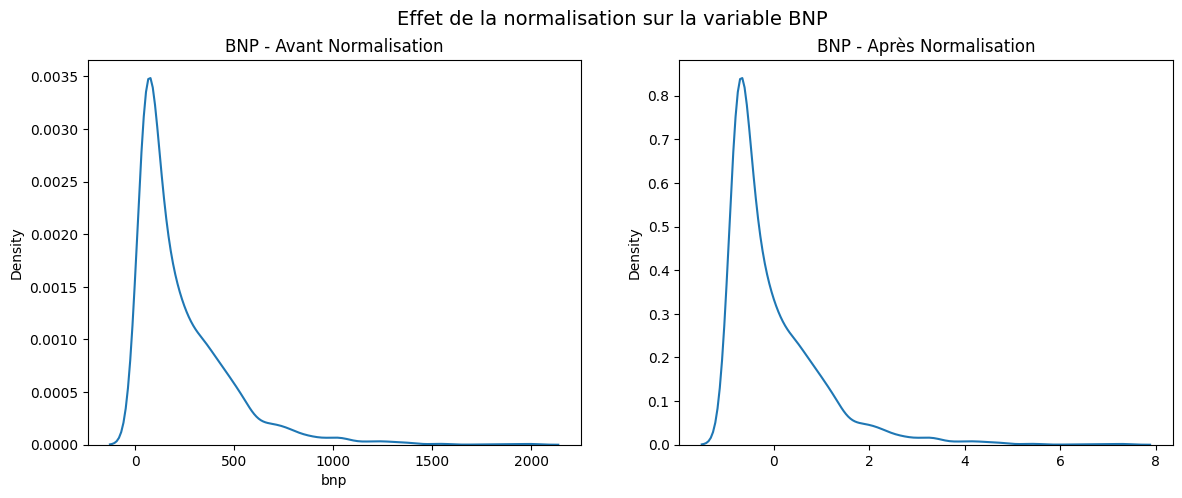

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Avant normalisation
sns.kdeplot(train_df['bnp'], ax=axs[0])
axs[0].set_title('BNP - Avant Normalisation')

# Après normalisation
sns.kdeplot(train_feats[:, 1], ax=axs[1])
axs[1].set_title('BNP - Après Normalisation')

plt.suptitle('Effet de la normalisation sur la variable BNP', fontsize=14)
plt.show()


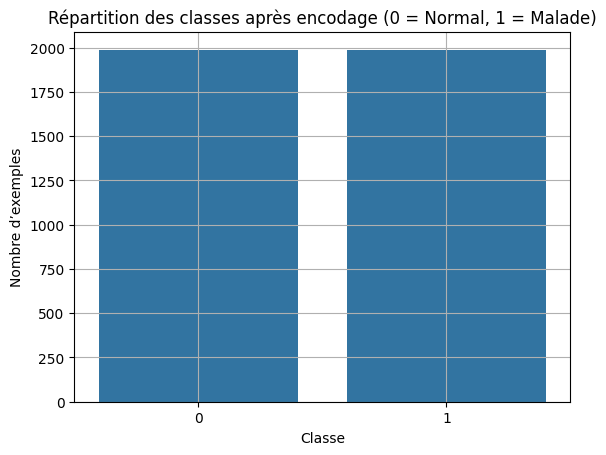

In [ ]:
import seaborn as sns

sns.countplot(x=train_df['label'])
plt.title("Répartition des classes après encodage (0 = Normal, 1 = Malade)")
plt.xlabel("Classe")
plt.ylabel("Nombre d’exemples")
plt.grid(True)
plt.show()


In [ ]:
print("Mapping des labels :")
for label, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{label} → {encoded}")


Mapping des labels :
Malade → 0
Normal → 1


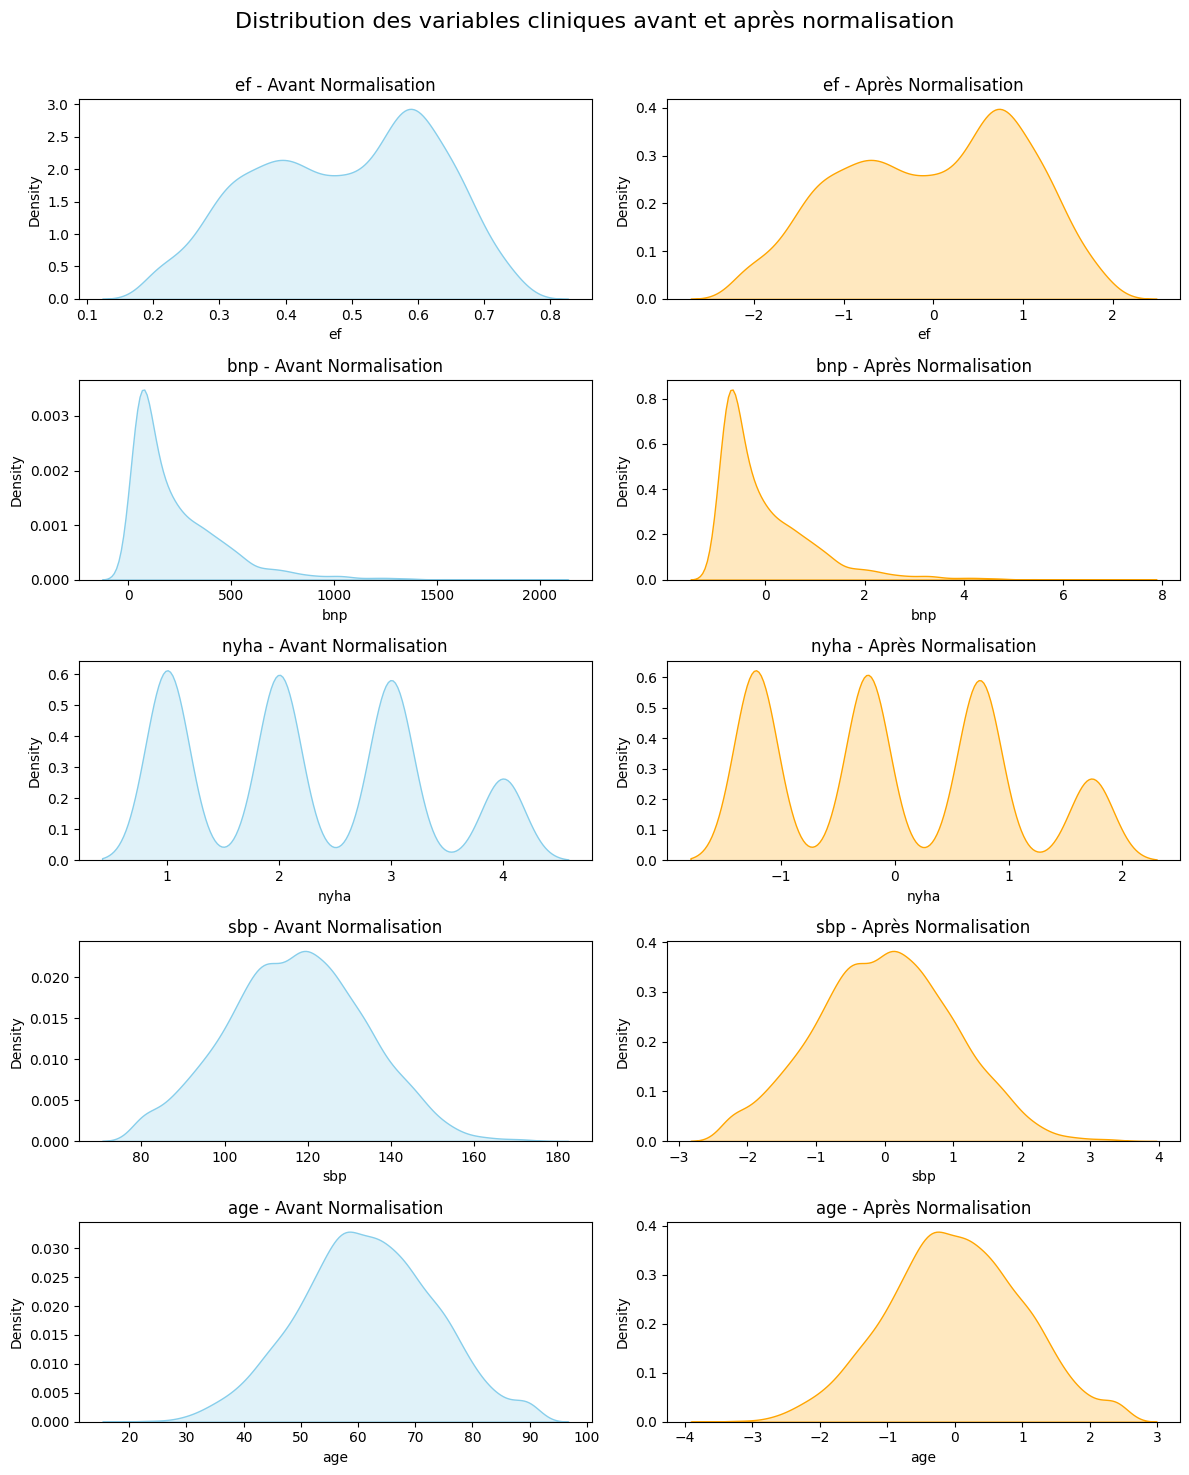

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# قائمة المتغيرات
features = ['ef', 'bnp', 'nyha', 'sbp', 'age']

# Normalized values من train_feats
normalized_df = pd.DataFrame(train_feats, columns=features)

# Subplots
fig, axs = plt.subplots(len(features), 2, figsize=(12, 15))
fig.suptitle("Distribution des variables cliniques avant et après normalisation", fontsize=16)

for i, feat in enumerate(features):
    sns.kdeplot(train_df[feat], ax=axs[i, 0], fill=True, color='skyblue')
    axs[i, 0].set_title(f"{feat} - Avant Normalisation")

    sns.kdeplot(normalized_df[feat], ax=axs[i, 1], fill=True, color='orange')
    axs[i, 1].set_title(f"{feat} - Après Normalisation")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [ ]:

normalized_df = pd.DataFrame(train_feats, columns=['ef', 'bnp', 'nyha', 'sbp', 'age'])
print("🔍 Aperçu des valeurs normalisées (Top 10 lignes):\n")
print(normalized_df.head(10))


🔍 Aperçu des valeurs normalisées (Top 10 lignes):

         ef       bnp      nyha       sbp       age
0  1.387369 -0.823828  0.745633 -0.207670 -0.378676
1  0.760972 -0.787688 -1.219655 -0.189465  0.468699
2 -1.766726 -0.244759 -1.219655 -1.045102  1.993974
3 -1.243500 -0.368229  0.745633  0.423438  0.977124
4  0.031403  0.008442  0.745633  0.684377  1.993974
5  1.262090  0.058442 -1.219655  2.650522 -0.209201
6  0.915729 -0.491728  0.745633 -1.348519 -1.819214
7 -2.032023  2.330656  0.745633 -0.238012  0.129749
8  1.247351 -0.841823 -0.237011  1.188050 -0.209201
9 -1.280347  1.826629 -1.219655 -0.474677  1.485549


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 133MB/s]


⏳ Extraction des features images pour train...


  0%|          | 0/4940 [00:00<?, ?it/s]

✅ Features images train sauvegardées dans /content/drive/MyDrive/datacombine4/train_image_features.npy
⏳ Extraction des features images pour val...


  0%|          | 0/942 [00:00<?, ?it/s]

✅ Features images val sauvegardées dans /content/drive/MyDrive/datacombine4/val_image_features.npy
⏳ Extraction des features images pour test...


  0%|          | 0/906 [00:00<?, ?it/s]

✅ Features images test sauvegardées dans /content/drive/MyDrive/datacombine4/test_image_features.npy
[Epoch 1] Loss: 0.6877 | Train Acc: 54.51% | Val Acc: 60.19%
[Epoch 2] Loss: 0.6120 | Train Acc: 61.72% | Val Acc: 71.44%
[Epoch 3] Loss: 0.5428 | Train Acc: 73.52% | Val Acc: 79.09%
[Epoch 4] Loss: 0.5051 | Train Acc: 80.20% | Val Acc: 82.70%
[Epoch 5] Loss: 0.4677 | Train Acc: 81.11% | Val Acc: 80.04%
[Epoch 6] Loss: 0.4265 | Train Acc: 81.82% | Val Acc: 83.01%
[Epoch 7] Loss: 0.4057 | Train Acc: 81.92% | Val Acc: 83.86%
[Epoch 8] Loss: 0.3693 | Train Acc: 83.26% | Val Acc: 85.14%
[Epoch 9] Loss: 0.3527 | Train Acc: 84.57% | Val Acc: 86.41%
[Epoch 10] Loss: 0.3153 | Train Acc: 86.92% | Val Acc: 88.32%
[Epoch 11] Loss: 0.3008 | Train Acc: 86.98% | Val Acc: 90.66%
[Epoch 12] Loss: 0.2822 | Train Acc: 87.79% | Val Acc: 91.19%
[Epoch 13] Loss: 0.2632 | Train Acc: 89.09% | Val Acc: 90.45%
[Epoch 14] Loss: 0.2406 | Train Acc: 90.57% | Val Acc: 91.30%
[Epoch 15] Loss: 0.2282 | Train Acc: 91.

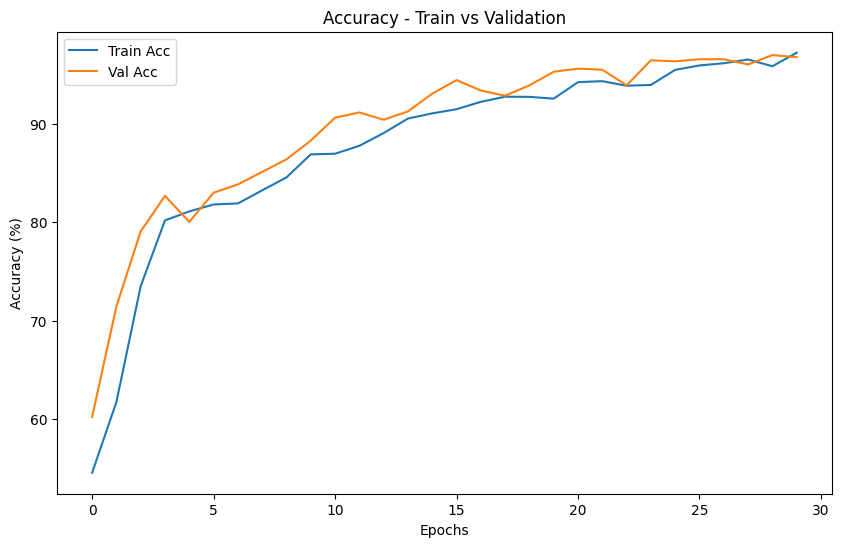

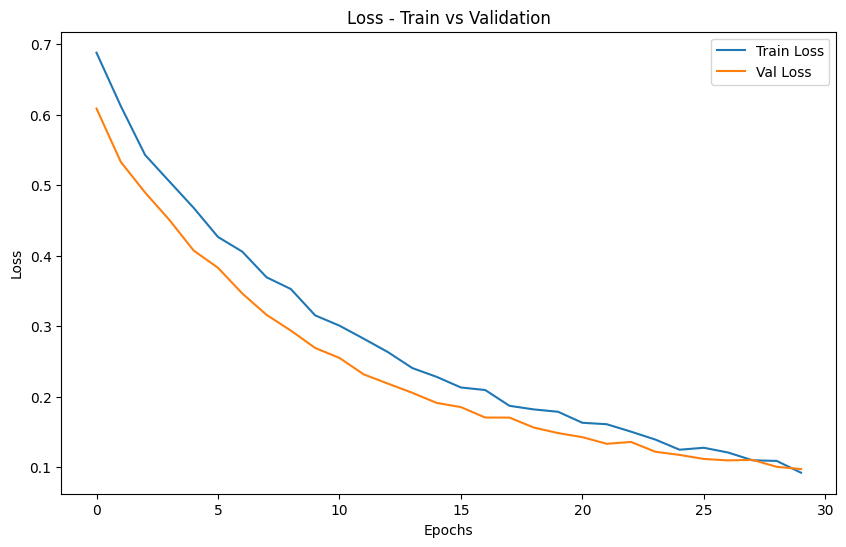


📊 Rapport Test
              precision    recall  f1-score   support

      Malade       0.99      0.97      0.98       678
      Normal       0.91      0.96      0.94       228

    accuracy                           0.97       906
   macro avg       0.95      0.97      0.96       906
weighted avg       0.97      0.97      0.97       906

✅ Modèle sauvegardé.


In [ ]:
import os
import torch
import pandas as pd
import numpy as np
from PIL import Image
from torchvision import models, transforms
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import kneighbors_graph
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import torch.nn as nn
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import joblib

# 📌 Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 📁 Paths
train_csv = '/content/drive/MyDrive/datacombine4/train_top5.csv'
val_csv   = '/content/drive/MyDrive/datacombine4/val_split.csv'
test_csv  = '/content/drive/MyDrive/datacombine4/test_top5.csv'
image_dir = '/content/drive/MyDrive/archive (10)/ECG_DATA'

# 📖 Load datasets
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

# 📊 Encode labels
label_encoder = LabelEncoder()
train_df['label'] = label_encoder.fit_transform(train_df['label'])
val_df['label']   = label_encoder.transform(val_df['label'])
test_df['label']  = label_encoder.transform(test_df['label'])

# 📏 Normalize top 5 features - normalisation basée seulement sur train
scaler = StandardScaler()
train_feats = scaler.fit_transform(train_df[['ef', 'bnp', 'nyha', 'sbp', 'age']])

# Pour val et test, appliquer même scaler sans ré-entraîner
val_feats   = scaler.transform(val_df[['ef', 'bnp', 'nyha', 'sbp', 'age']])
test_feats  = scaler.transform(test_df[['ef', 'bnp', 'nyha', 'sbp', 'age']])

# 💾 Sauvegarder scaler et label encoder
os.makedirs('/content/drive/MyDrive/datacombine4', exist_ok=True)
joblib.dump(scaler, '/content/drive/MyDrive/datacombine4/scaler_top5.pkl')
joblib.dump(label_encoder, '/content/drive/MyDrive/datacombine4/label_encoder.pkl')

# 📸 Image transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 🖼️ Load ResNet18 sans FC layer
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device)
resnet.eval()

# 🔍 Function: Extract image features
def extract_image_feature(path):
    try:
        image_path = os.path.join(image_dir, path)
        image = Image.open(image_path).convert('RGB')
        image = transform(image).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = resnet(image).squeeze().cpu().numpy()
        return feat
    except Exception as e:
        print(f"⚠️ Erreur sur {path} : {e}")
        return np.zeros(512)

# 💾 Fonction pour extraire et sauvegarder les features images
def extract_and_save_image_features(df, split_name):
    features_path = f'/content/drive/MyDrive/datacombine4/{split_name}_image_features.npy'
    if os.path.exists(features_path):
        print(f"🟢 {split_name} image features loaded from cache.")
        return np.load(features_path)
    print(f"⏳ Extraction des features images pour {split_name}...")
    feats = np.array([extract_image_feature(p) for p in tqdm(df['image_path'])])
    np.save(features_path, feats)
    print(f"✅ Features images {split_name} sauvegardées dans {features_path}")
    return feats

# 📊 Build graph data
def build_graph(df, clinical_feats, split_name):
    image_feats = extract_and_save_image_features(df, split_name)
    all_feats   = np.concatenate([image_feats, clinical_feats], axis=1)
    x = torch.tensor(all_feats, dtype=torch.float)
    y = torch.tensor(df['label'].values, dtype=torch.long)

    # KNN graph (5 voisins)
    knn_graph = kneighbors_graph(all_feats, n_neighbors=5, mode='connectivity', include_self=False)
    edge_index = torch.tensor(np.array(knn_graph.nonzero()), dtype=torch.long)

    edge_index_with_loops = torch_geometric.utils.add_self_loops(edge_index)[0]


    return Data(x=x, edge_index=edge_index_with_loops, y=y)


train_data = build_graph(train_df, train_feats, 'train').to(device)
val_data   = build_graph(val_df, val_feats, 'val').to(device)
test_data  = build_graph(test_df, test_feats, 'test').to(device)

# 📌 GCN Model
class GlobalGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        return self.classifier(x)

# 📏 Paramètres
EPOCHS = 30
in_channels = 512 + 5  # ResNet feature dim + top5 clinical features
model = GlobalGCN(in_channels=in_channels, hidden_channels=128, out_channels=len(label_encoder.classes_)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_accs, val_accs, train_losses, val_losses = [], [], [], []

# 📊 Entraînement
for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    out = model(train_data)
    loss = criterion(out, train_data.y)
    loss.backward()
    optimizer.step()

    pred = out.argmax(dim=1)
    acc = (pred == train_data.y).sum().item() / train_data.num_nodes
    train_accs.append(acc * 100)
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_out = model(val_data)
        val_pred = val_out.argmax(dim=1)
        val_acc = (val_pred == val_data.y).sum().item() / val_data.num_nodes
        val_accs.append(val_acc * 100)
        val_loss = criterion(val_out, val_data.y).item()
        val_losses.append(val_loss)

    print(f"[Epoch {epoch}] Loss: {loss.item():.4f} | Train Acc: {acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

# 📈 Courbes
plt.figure(figsize=(10,6))
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel("Epochs"); plt.ylabel("Accuracy (%)")
plt.title("Accuracy - Train vs Validation")
plt.legend(); plt.show()

plt.figure(figsize=(10,6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.title("Loss - Train vs Validation")
plt.legend(); plt.show()

# 📊 Évaluation test
model.eval()
with torch.no_grad():
    test_out = model(test_data)
    test_pred = test_out.argmax(dim=1)
    y_true = test_data.y.cpu().numpy()
    y_pred = test_pred.cpu().numpy()

print("\n📊 Rapport Test")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# 💾 Sauvegarde modèle + scaler + label_encoder
torch.save(model.state_dict(), '/content/drive/MyDrive/datacombine4/model_gcn_top5.pth')
print("✅ Modèle sauvegardé.")


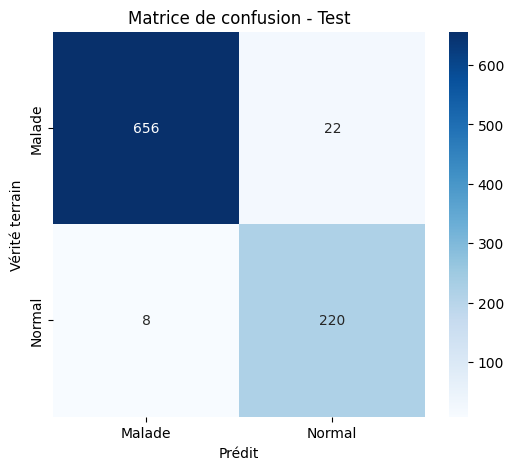

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 📊 Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Prédit')
plt.ylabel('Vérité terrain')
plt.title('Matrice de confusion - Test')
plt.show()


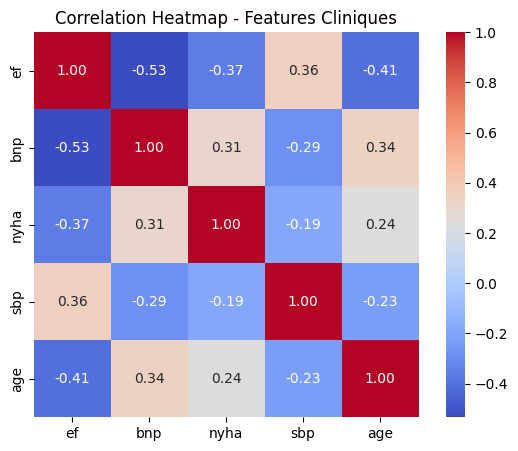

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 📌 Sélection des colonnes cliniques
clinical_columns = ['ef', 'bnp', 'nyha', 'sbp', 'age']

# 📌 Calcul de la matrice de corrélation
corr_matrix = df_train_final[clinical_columns].corr()

# 📊 Heatmap avec Seaborn
plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap - Features Cliniques')
plt.show()


n_classes: 2  | y_score shape: (906, 2)


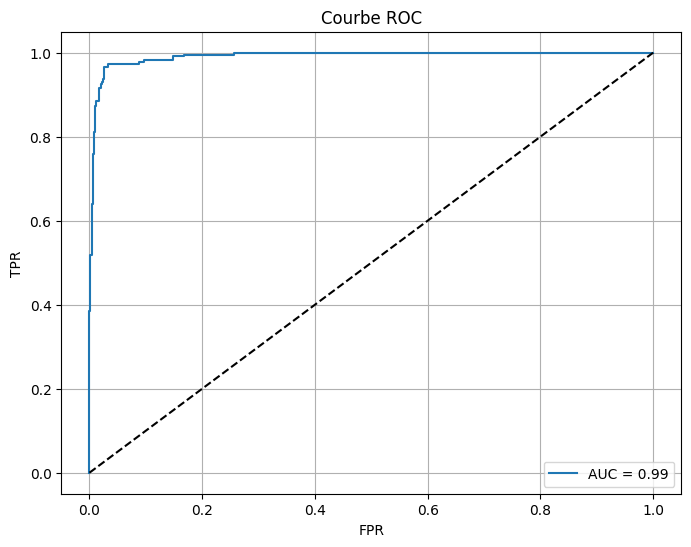

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import torch.nn.functional as F

with torch.no_grad():
    test_out = model(test_data)
    y_score = F.softmax(test_out, dim=1).cpu().numpy()   # proba par classe
    y_true  = test_data.y.cpu().numpy()

n_classes = y_score.shape[1]
print("n_classes:", n_classes, " | y_score shape:", y_score.shape)

plt.figure(figsize=(8, 6))

if n_classes == 2:
    # ROC binaire : une seule courbe
    fpr, tpr, _ = roc_curve(y_true, y_score[:, 1])  # classe positive = colonne 1
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
else:
    # ROC multi‑classe
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("Courbe ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
import os
import torch
import pandas as pd
import numpy as np
from PIL import Image
from torchvision import models, transforms
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import kneighbors_graph
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import torch.nn as nn
import joblib

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paths
val_csv     = '/content/drive/MyDrive/datacombine4/val_split.csv'
image_dir   = '/content/drive/MyDrive/archive (10)/ECG_DATA'
model_path  = '/content/drive/MyDrive/datacombine3/model_gcn_top5.pth'
scaler_path = '/content/drive/MyDrive/datacombine3/scaler_top5.pkl'
encoder_path= '/content/drive/MyDrive/datacombine3/label_encoder.pkl'
val_feat_path = '/content/drive/MyDrive/datacombine4/val_image_features.npy'

# Load val set et encoder
val_df = pd.read_csv(val_csv)
label_encoder = joblib.load(encoder_path)
val_df['label'] = label_encoder.transform(val_df['label'])

# Load scaler et normaliser val set
scaler = joblib.load(scaler_path)
val_feats = scaler.transform(val_df[['ef', 'bnp', 'nyha', 'sbp', 'age']])

# Load image features déjà extraites
val_image_feats = np.load(val_feat_path)

# ResNet extractor pour le patient
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device)
resnet.eval()

def extract_image_feature(path):
    image_path = os.path.join(image_dir, path)
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = resnet(image).squeeze().cpu().numpy()
    return feat

# Patient à tester
patient_dict = {
    'image_path': '/content/drive/MyDrive/archive (10)/ECG_DATA/test/MI/MI(100).jpg',
    'label': 'Malade',
    'ef': 0.334,
    'bnp': 463.331,
    'nyha': 3,
    'sbp': 132,
    'age': 70
}
patient_feats_raw = np.array([[patient_dict['ef'], patient_dict['bnp'],
                               patient_dict['nyha'], patient_dict['sbp'],
                               patient_dict['age']]])
patient_feats = scaler.transform(patient_feats_raw)
patient_img_feat = extract_image_feature(patient_dict['image_path'])

# Graph construction
all_feats = np.concatenate([val_image_feats, val_feats], axis=1)
patient_all_feat = np.concatenate([patient_img_feat, patient_feats.squeeze()])
all_feats = np.vstack([all_feats, patient_all_feat])

labels = np.concatenate([val_df['label'].values, [-1]])
knn_graph = kneighbors_graph(all_feats, n_neighbors=5, mode='connectivity', include_self=False)
edge_index = torch.tensor(np.array(knn_graph.nonzero()), dtype=torch.long)

data = Data(x=torch.tensor(all_feats, dtype=torch.float),
            edge_index=edge_index,
            y=torch.tensor(labels, dtype=torch.long)).to(device)

# Modèle
class GlobalGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, out_channels)
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        return self.classifier(x)

model = GlobalGCN(in_channels=517, hidden_channels=128, out_channels=len(label_encoder.classes_)).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Prédiction patient
with torch.no_grad():
    out = model(data)
    pred = out.argmax(dim=1)
    patient_pred_class = label_encoder.inverse_transform([pred[-1].cpu().item()])[0]
print(f"✅ Patient MI(100).jpg prédit comme : {patient_pred_class}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


✅ Patient MI(100).jpg prédit comme : Malade


<ipython-input-21-70b45c5b3736>:100: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


In [ ]:
import os
import torch
import pandas as pd
import numpy as np
from PIL import Image
from torchvision import models, transforms
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import kneighbors_graph
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import torch.nn as nn
import joblib

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paths
val_csv     = '/content/drive/MyDrive/datacombine4/val_split.csv'
image_dir   = '/content/drive/MyDrive/archive (10)/ECG_DATA'
model_path  = '/content/drive/MyDrive/datacombine3/model_gcn_top5.pth'
scaler_path = '/content/drive/MyDrive/datacombine3/scaler_top5.pkl'
encoder_path= '/content/drive/MyDrive/datacombine3/label_encoder.pkl'
val_feat_path = '/content/drive/MyDrive/datacombine4/val_image_features.npy'

# Load val set et encoder
val_df = pd.read_csv(val_csv)
label_encoder = joblib.load(encoder_path)
val_df['label'] = label_encoder.transform(val_df['label'])

# Load scaler et normaliser val set
scaler = joblib.load(scaler_path)
val_feats = scaler.transform(val_df[['ef', 'bnp', 'nyha', 'sbp', 'age']])

# Load image features déjà extraites
val_image_feats = np.load(val_feat_path)

# ResNet extractor pour le patient
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device)
resnet.eval()

def extract_image_feature(path):
    image_path = os.path.join(image_dir, path)
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = resnet(image).squeeze().cpu().numpy()
    return feat

# Patient à tester
patient_dict = {
    'image_path': '/content/drive/MyDrive/archive (10)/ECG_DATA/test/Normal/Normal(90).jpg',
    'label': 'Malade',
    'ef': 0.464,
    'bnp': 26.882,
    'nyha': 2,
    'sbp': 111.9,
    'age': 73
}
patient_feats_raw = np.array([[patient_dict['ef'], patient_dict['bnp'],
                               patient_dict['nyha'], patient_dict['sbp'],
                               patient_dict['age']]])
patient_feats = scaler.transform(patient_feats_raw)
patient_img_feat = extract_image_feature(patient_dict['image_path'])

# Graph construction
all_feats = np.concatenate([val_image_feats, val_feats], axis=1)
patient_all_feat = np.concatenate([patient_img_feat, patient_feats.squeeze()])
all_feats = np.vstack([all_feats, patient_all_feat])

labels = np.concatenate([val_df['label'].values, [-1]])
knn_graph = kneighbors_graph(all_feats, n_neighbors=5, mode='connectivity', include_self=False)
edge_index = torch.tensor(np.array(knn_graph.nonzero()), dtype=torch.long)

data = Data(x=torch.tensor(all_feats, dtype=torch.float),
            edge_index=edge_index,
            y=torch.tensor(labels, dtype=torch.long)).to(device)

# Modèle
class GlobalGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, out_channels)
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        return self.classifier(x)

model = GlobalGCN(in_channels=517, hidden_channels=128, out_channels=len(label_encoder.classes_)).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Prédiction patient
with torch.no_grad():
    out = model(data)
    pred = out.argmax(dim=1)
    patient_pred_class = label_encoder.inverse_transform([pred[-1].cpu().item()])[0]
print(f"✅ Patient MI(100).jpg prédit comme : {patient_pred_class}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
<ipython-input-22-8a66832beef1>:100: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the

✅ Patient MI(100).jpg prédit comme : Normal


In [ ]:
import os
import torch
import pandas as pd
import numpy as np
from PIL import Image
from torchvision import models, transforms
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import kneighbors_graph
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
import torch.nn as nn
import joblib

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paths
val_csv     = '/content/drive/MyDrive/datacombine4/val_split.csv'
image_dir   = '/content/drive/MyDrive/archive (10)/ECG_DATA'
model_path  = '/content/drive/MyDrive/datacombine3/model_gcn_top5.pth'
scaler_path = '/content/drive/MyDrive/datacombine3/scaler_top5.pkl'
encoder_path= '/content/drive/MyDrive/datacombine3/label_encoder.pkl'
val_feat_path = '/content/drive/MyDrive/datacombine4/val_image_features.npy'

# Load val set et encoder
val_df = pd.read_csv(val_csv)
label_encoder = joblib.load(encoder_path)
val_df['label'] = label_encoder.transform(val_df['label'])

# Load scaler et normaliser val set
scaler = joblib.load(scaler_path)
val_feats = scaler.transform(val_df[['ef', 'bnp', 'nyha', 'sbp', 'age']])

# Load image features déjà extraites
val_image_feats = np.load(val_feat_path)

# ResNet extractor pour le patient
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device)
resnet.eval()

def extract_image_feature(path):
    image_path = os.path.join(image_dir, path)
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = resnet(image).squeeze().cpu().numpy()
    return feat

# Patient à tester
patient_dict = {
    'image_path': '/content/drive/MyDrive/archive (10)/ECG_DATA/test/Normal/Normal(248).jpg',
    'label': 'Malade',
    'ef': 0.68,
    'bnp': 59.497,
    'nyha': 2,
    'sbp': 130.7,
    'age': 54
}
patient_feats_raw = np.array([[patient_dict['ef'], patient_dict['bnp'],
                               patient_dict['nyha'], patient_dict['sbp'],
                               patient_dict['age']]])
patient_feats = scaler.transform(patient_feats_raw)
patient_img_feat = extract_image_feature(patient_dict['image_path'])

# Graph construction
all_feats = np.concatenate([val_image_feats, val_feats], axis=1)
patient_all_feat = np.concatenate([patient_img_feat, patient_feats.squeeze()])
all_feats = np.vstack([all_feats, patient_all_feat])

labels = np.concatenate([val_df['label'].values, [-1]])
knn_graph = kneighbors_graph(all_feats, n_neighbors=5, mode='connectivity', include_self=False)
edge_index = torch.tensor(np.array(knn_graph.nonzero()), dtype=torch.long)

data = Data(x=torch.tensor(all_feats, dtype=torch.float),
            edge_index=edge_index,
            y=torch.tensor(labels, dtype=torch.long)).to(device)

# Modèle
class GlobalGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, out_channels)
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        return self.classifier(x)

model = GlobalGCN(in_channels=517, hidden_channels=128, out_channels=len(label_encoder.classes_)).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Prédiction patient
with torch.no_grad():
    out = model(data)
    pred = out.argmax(dim=1)
    patient_pred_class = label_encoder.inverse_transform([pred[-1].cpu().item()])[0]
print(f"✅ Patient MI(100).jpg prédit comme : {patient_pred_class}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


✅ Patient MI(100).jpg prédit comme : Normal


<ipython-input-23-37c51bc315f5>:100: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


**Streamlit Web Interface.**

In [ ]:
!pip install streamlit -q

In [ ]:
!wget -q -O - ipv4.icanhazip.com

34.106.184.52


In [ ]:
! streamlit run interface.py & npx localtunnel --port 8501

⠙Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: interface.py
⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦your url is: https://big-buses-notice.loca.lt


In [ ]:
!pip install pyngrok streamlit -q

In [ ]:
import streamlit as st
import torch
import torch.nn.functional as F
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import kneighbors_graph
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from PIL import Image
from torchvision import models, transforms
import joblib
import os
import matplotlib.pyplot as plt

# 📌 Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 📖 Chemins
val_csv = '/content/drive/MyDrive/datacombine4/val_split.csv'
val_feats_path = '/content/drive/MyDrive/datacombine4/val_image_features.npy'
scaler_path = '/content/drive/MyDrive/datacombine4/scaler_top5.pkl'
model_path = '/content/drive/MyDrive/datacombine4/model_gcn_top5.pth'
encoder_path = '/content/drive/MyDrive/datacombine4/label_encoder.pkl'

# 📊 Load val DataFrame et features
val_df = pd.read_csv(val_csv)
val_image_feats = np.load(val_feats_path)

# 📊 Load scaler et label_encoder
scaler = joblib.load(scaler_path)
label_encoder = joblib.load(encoder_path)

# 📸 Image transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 🖼️ Load ResNet18 sans FC layer
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device)
resnet.eval()

# 📌 Modèle GCN
class GlobalGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        return self.classifier(x)

# 📌 Load modèle
model = GlobalGCN(in_channels=517, hidden_channels=128, out_channels=len(label_encoder.classes_)).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
# === Interface utilisateur améliorée ===
st.markdown(
    "<h1 style='text-align: center;'> Prédiction de l’insuffisance cardiaque par GCN</h1>",
    unsafe_allow_html=True
)
st.markdown(
    "<p style='text-align: center; color: gray;'>Analyse d’image ECG combinée aux données du patient pour déterminer son état clinique.</p>",
    unsafe_allow_html=True
)

st.markdown("---")

# 📥 Input du chemin image
image_path = st.text_input("Entrez le chemin de l'image ECG :", value="/content/drive/MyDrive/archive (10)/ECG_DATA/test/MI/MI(100).jpg")

st.markdown("#####  Données Cliniques")
# 📊 Variables cliniques
ef = st.number_input("Fraction d'éjection (EF)", 0.0, 1.0, 0.5000,
                     step=0.0001, format="%.4f")
bnp = st.number_input("Brain Natriuretic Peptide (BNP)", 0.0, 5000.0, 300.00,
                      step=1.0, format="%.3f")
nyha = st.selectbox("New York Heart Association (NYHA)", [1, 2, 3, 4], index=1)
sbp = st.number_input(
    "Systolic Blood Pressure (SBP)",
    min_value=50.0,
    max_value=250.0,
    value=120.0,
    step=0.1,
    format="%.1f"
)
age = st.number_input("Âge", 20, 100, 60)

# Centrage du bouton
col_btn1, col_btn2, col_btn3 = st.columns([1, 1, 1])
with col_btn2:
    predict = st.button("🔍 Lancer la prédiction")

# === Action prédiction ===
if predict:
    try:
        # Extract image features
        image_ecg = Image.open(image_path).convert('RGB')
        image_ecg_transformed = transform(image_ecg).unsqueeze(0).to(device)
        with torch.no_grad():
            image_feat = resnet(image_ecg_transformed).squeeze().cpu().numpy()

        # Clinical features
        clinical_feats = np.array([[ef, bnp, nyha, sbp, age]])
        clinical_feats_norm = scaler.transform(clinical_feats)

        # Combine avec val
        all_image_feats = np.vstack([val_image_feats, image_feat.reshape(1, -1)])
        all_clinical_feats = np.vstack([scaler.transform(val_df[['ef','bnp','nyha','sbp','age']]), clinical_feats_norm])

        # Concatenate
        all_feats = np.concatenate([all_image_feats, all_clinical_feats], axis=1)

        # Edge index via k-NN
        knn_graph = kneighbors_graph(all_feats, n_neighbors=5, mode='connectivity', include_self=False)
        edge_index = torch.tensor(np.array(knn_graph.nonzero()), dtype=torch.long)

        # Labels
        val_labels_encoded = label_encoder.transform(val_df['label'].values)
        y = torch.tensor(np.concatenate([val_labels_encoded, [0]]), dtype=torch.long)

        # Graph data
        data_graph = Data(x=torch.tensor(all_feats, dtype=torch.float),
                          edge_index=edge_index,
                          y=y).to(device)

        # Prédiction
        with torch.no_grad():
            out = model(data_graph)
            pred = out.argmax(dim=1).cpu().numpy()[-1]

        st.success(f"✅ Le patient est : **{label_encoder.inverse_transform([pred])[0]}**")

        # 📸 Afficher image après prédiction
        st.image(image_ecg, caption="ECG du patient", use_container_width=True)

    except Exception as e:
        st.error(f"❌ Erreur : {e}")
